In [1]:
!pip install dask dask[distributed]

import dask.dataframe as dd
import matplotlib.pyplot as plt
import seaborn as sns
import dask.distributed
from dask.diagnostics import ProgressBar, Profiler, visualize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.0 MB/s eta 0:00:00


In [2]:
DATASET_URL = "https://raw.githubusercontent.com/gakudo-ai/open-datasets/refs/heads/main/CTA_-_Ridership_-_Daily_Boarding_Totals.csv"

# Función para obtener y preparar el dataset: series temporales con registros diarios del índice de pasajeros de transporte público en Chicago
def prepare_time_series(url):
    ddf = dd.read_csv(url, parse_dates=['service_date'])

    ddf['DayOfWeek'] = ddf['service_date'].dt.dayofweek
    ddf['Month'] = ddf['service_date'].dt.month
    ddf['IsWeekend'] = ddf['DayOfWeek'].isin([5, 6]).astype(int)

    return ddf

In [4]:
# Función para llevar a cabo un análisis de series temporales
def advanced_time_series_analysis(ddf):

    with Profiler() as prof:
        with ProgressBar():
            # Agregar datos diarios en resúmenes trimestrales
            quarterly_stats = (
                ddf.groupby([ddf['service_date'].dt.year, ddf['service_date'].dt.quarter])['total_rides']
                .agg(['sum', 'mean', 'count', 'std'])
                .compute()
            )

            pdf = ddf.compute()

            # Creación de cuatro gráficos de visualización
            plt.figure(figsize=(15, 10))

            plt.subplot(2, 2, 1)
            quarterly_stats['sum'].plot(kind='line', title='Quarterly Total Boardings')
            plt.xlabel('Year-Quarter')
            plt.ylabel('Total Boardings')
            plt.xticks(rotation=45)

            plt.subplot(2, 2, 2)
            quarterly_stats['std'].plot(kind='bar', title='Quarterly Boarding Variability')
            plt.xlabel('Year-Quarter')
            plt.ylabel('Standard Deviation')
            plt.xticks(rotation=45)

            plt.subplot(2, 2, 3)
            weekday_stats = pdf[pdf['IsWeekend'] == 0]['total_rides']
            weekend_stats = pdf[pdf['IsWeekend'] == 1]['total_rides']
            plt.boxplot([weekday_stats, weekend_stats], labels=['Weekday', 'Weekend'])
            plt.title('Boarding Distribution: Weekday vs Weekend')
            plt.ylabel('Total Boardings')

            plt.subplot(2, 2, 4)
            seasonal_pivot = pdf.pivot_table(
                index='Month',
                columns=pdf['service_date'].dt.year,
                values='total_rides',
                aggfunc='mean'
            )
            plt.imshow(seasonal_pivot, cmap='YlGnBu', aspect='auto')
            plt.colorbar(label='Avg. Boardings')
            plt.title('Seasonal Boarding Heatmap')
            plt.xlabel('Year')
            plt.ylabel('Month')

            plt.tight_layout()
            plt.show()

    visualize(prof)

    return quarterly_stats

INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:39007
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:36129'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:46473'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:44695 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:44695
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:50370
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:35519 name: 1
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:35519
INFO:distributed.core:Starting established connection to tcp://127

Dask Dashboard URL: http://127.0.0.1:8787/status


/tmp/ipykernel_1147/3226576821.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([weekday_stats, weekend_stats], labels=['Weekday', 'Weekend'])


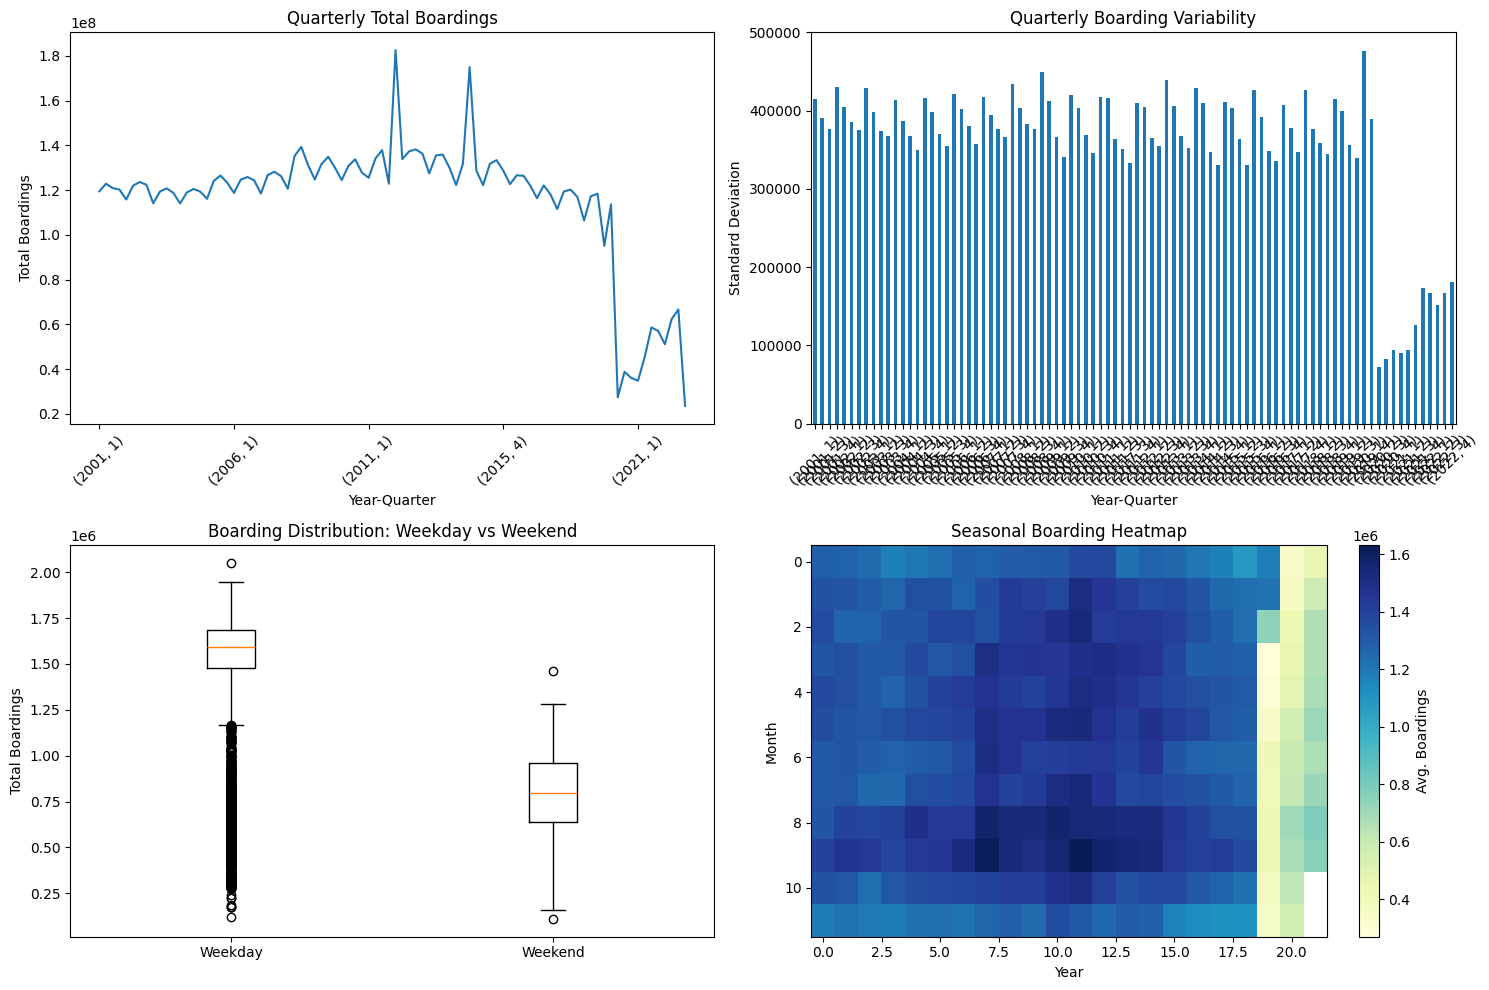

INFO:distributed.scheduler:Remove client Client-ca2e2c36-aed3-11f1-847b-0242ac1c000c
INFO:distributed.core:Received 'close-stream' from tcp://127.0.0.1:60798; closing.
INFO:distributed.scheduler:Remove client Client-ca2e2c36-aed3-11f1-847b-0242ac1c000c
INFO:distributed.scheduler:Close client connection: Client-ca2e2c36-aed3-11f1-847b-0242ac1c000c
INFO:distributed.scheduler:Retire worker addresses (stimulus_id='retire-workers-1789236017.326549') (0, 1)
INFO:distributed.nanny:Closing Nanny at 'tcp://127.0.0.1:36129'. Reason: nanny-close
INFO:distributed.nanny:Nanny asking worker to close. Reason: nanny-close
INFO:distributed.nanny:Closing Nanny at 'tcp://127.0.0.1:46473'. Reason: nanny-close
INFO:distributed.nanny:Nanny asking worker to close. Reason: nanny-close
INFO:distributed.core:Received 'close-stream' from tcp://127.0.0.1:50370; closing.
INFO:distributed.core:Received 'close-stream' from tcp://127.0.0.1:60784; closing.
INFO:distributed.scheduler:Remove worker addr: tcp://127.0.0.1


Quarterly Ridership Statistics:
                                 sum          mean  count            std
service_date service_date                                               
2001         1             119464146  1.327379e+06     90  414382.163454
             2             122835569  1.349841e+06     91  390145.157073
             3             120878456  1.313896e+06     92  377016.351655
             4             120227586  1.306822e+06     92  429737.152536
2002         1             115775156  1.286391e+06     90  404905.943323
...                              ...           ...    ...            ...
2021         4              57095640  6.206048e+05     92  173110.966947
2022         1              51122612  5.680290e+05     90  166575.867387
             2              62381411  6.855100e+05     91  151206.910674
             3              66662974  7.245975e+05     92  167509.373303
             4              23576296  7.605257e+05     31  180793.919850

[88 rows x 4 colu

INFO:distributed.nanny:Nanny at 'tcp://127.0.0.1:46473' closed.
INFO:distributed.nanny:Nanny at 'tcp://127.0.0.1:36129' closed.
INFO:distributed.scheduler:Closing scheduler. Reason: unknown
INFO:distributed.scheduler:Scheduler closing all comms


In [5]:
def main():
    client = dask.distributed.Client()
    print("Dask Dashboard URL:", client.dashboard_link)

    try:
        ddf = prepare_time_series(DATASET_URL)
        quarterly_stats = advanced_time_series_analysis(ddf)

        print("\nQuarterly Ridership Statistics:")
        print(quarterly_stats)

    finally:
        client.close()

if __name__ == "__main__":
    main()

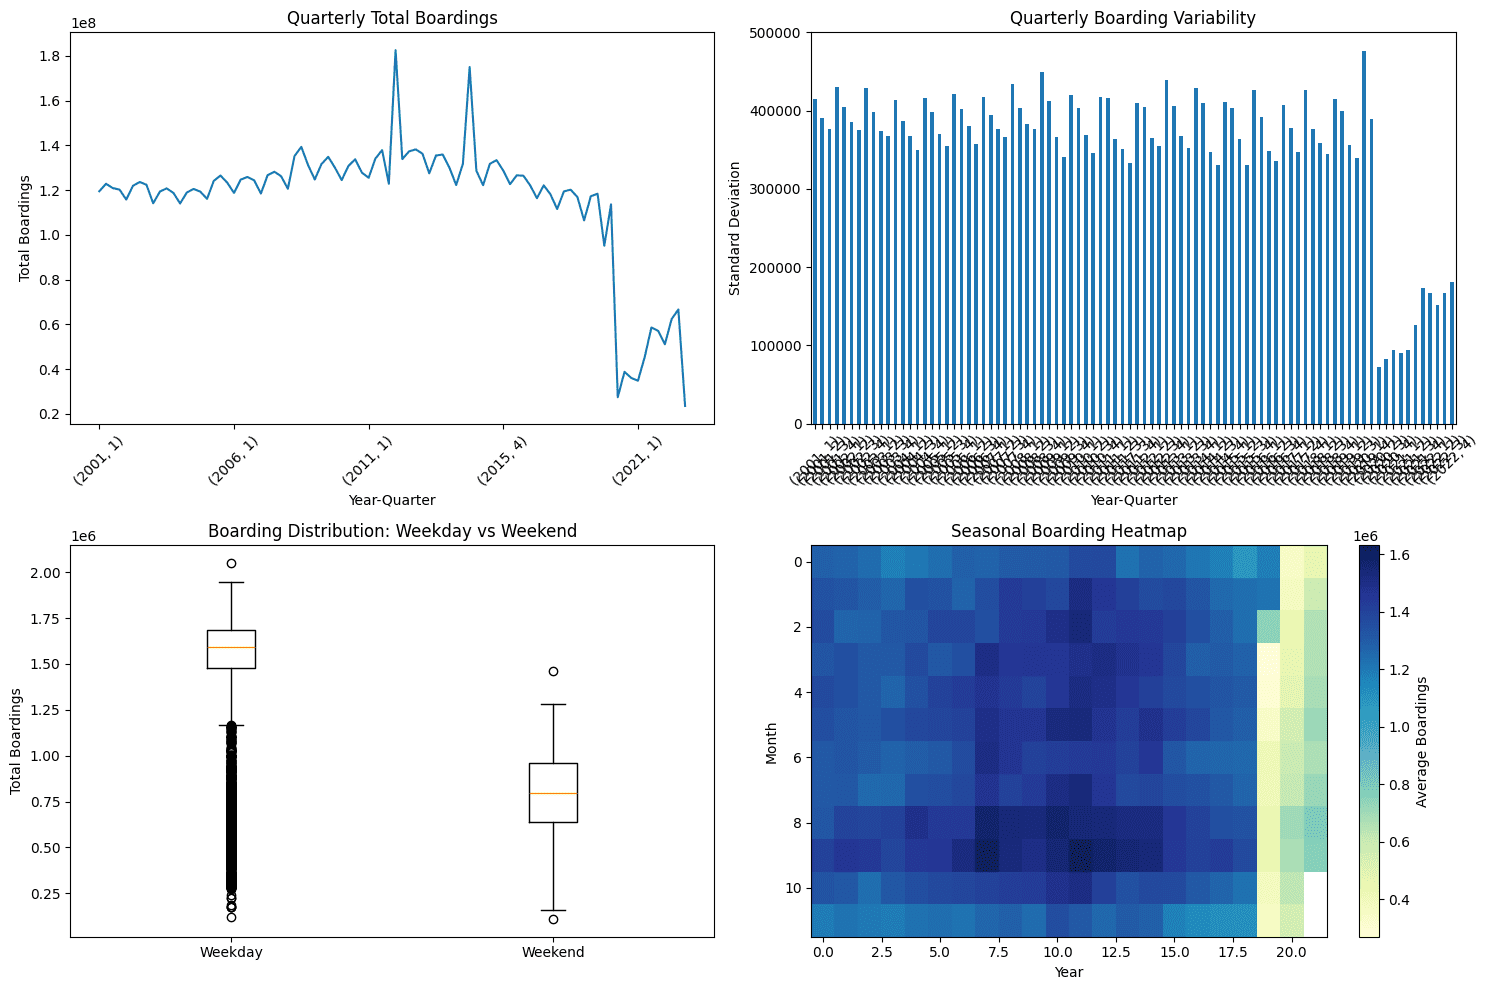